# Sentiment Analysis with BERT

## Project Overview

This notebook fine-tunes `bert-base-uncased` for 3-class sentiment classification using the Stanford Sentiment Treebank (SST) dataset. The task is to classify movie-review sentences as negative, neutral, or positive.

The goal of this analysis is to compare a pretrained Transformer-based model with my previous hybrid CNN-BiLSTM-Attention model trained on the same SST dataset. While the LSTM-based model learned sequence patterns primarily from the task data, BERT starts from pretrained language representations learned from large-scale text and uses self-attention to create contextual sentence representations.

This experiment evaluates whether fine-tuning BERT improves performance over the earlier LSTM approach and analyzes remaining classification challenges, especially confusion involving the neutral class.

In [ ]:
# Uncomment if libraries are not installed
# !pip install transformers datasets torch seaborn scikit-learn tqdm

In [26]:
# PyTorch
import torch
from torch import nn
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader

# torchtext SST dataset
from torchtext import data
from torchtext import datasets

# Transformers
from transformers import (
    BertTokenizer,
    BertForSequenceClassification
)

# Visualization / evaluation
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Progress bar
from tqdm.auto import tqdm

In [27]:
# Load Stanford Sentiment Treebank (SST) train/validation/test splits using torchtext

# Define preprocessing rules for input text and sentiment labels
TEXT = data.Field(lower=True) 
# Converts input text to lowercase before tokenization/vocabulary processing

LABEL = data.LabelField() 
# Handles sentiment labels (negative, neutral, positive)

# Download and split SST dataset
train_data, val_data, test_data = datasets.SST.splits(
    TEXT, # Apply text preprocessing rules
    LABEL # Apply label processing rules
)

# Build mapping from label strings to integer class IDs
LABEL.build_vocab(train_data)

In [28]:
# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [ ]:
# Load pretrained BERT tokenizer from Hugging Face
model_name = "bert-base-uncased"

# The tokenizer converts raw sentences into BERT token IDs
# and automatically adds special tokens such as [CLS] and [SEP]
tokenizer = BertTokenizer.from_pretrained(model_name)

In [30]:
# This Dataset class bridges the torchtext SST dataset and the input format required by BERT
# Flow:
# SST example -> sentence string -> BERT tokenizer
# -> token IDs + attention mask -> PyTorch tensors

from torch.utils.data import Dataset 
# PyTorch base class for creating custom datasets

class SSTBertDataset(Dataset):

    def __init__(self, examples, tokenizer, label_vocab, max_len=128): # Store following values

        # Store dataset examples and preprocessing components
        self.examples = examples  # SST sentence examples from torchtext
        self.tokenizer = tokenizer # Pretrained BERT tokenizer
        self.label_vocab = label_vocab  # Mapping from label strings to integer IDs
        self.max_len = max_len # Maximum sequence length for BERT inputs

    def __len__(self):
        # Number of examples in the dataset
        return len(self.examples) 
        
    def __getitem__(self, idx): # Tells Pytorch how to retrieve one example

         # Retrieve one SST example by index
        example = self.examples[idx]

        # Convert token list back into sentence string
        # Example:
        # ['the', 'movie', 'was', 'amazing']
        # -> "the movie was amazing"
        text = " ".join(example.text)  

        # Convert label string into integer class ID
        label = self.label_vocab.stoi[example.label] 

        # Tokenize sentence for BERT
        # Adds [CLS] and [SEP] tokens automatically
        # Pads/truncates sequences to max_len
        encoding = self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt" 
        )

        # Return one training example in the format expected by BERT
        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.long)
        }

In [31]:
# Create PyTorch Dataset objects for training, validation, and testing
train_dataset = SSTBertDataset(
    train_data,
    tokenizer,
    LABEL.vocab
)

val_dataset = SSTBertDataset(
    val_data,
    tokenizer,
    LABEL.vocab
)

test_dataset = SSTBertDataset(
    test_data,
    tokenizer,
    LABEL.vocab
)

In [32]:
# Create DataLoaders to feed mini-batches into BERT during training/evaluation
train_loader = DataLoader(
    train_dataset, 
    batch_size=8, 
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8
)

In [ ]:
# Load pretrained BERT model for sentiment classification
model = BertForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3
)

# Move model to GPU if available
model.to(device)

In [33]:
# Define optimizer for BERT fine-tuning
optimizer = AdamW(
    model.parameters(),
    lr=2e-5,
    weight_decay=0.01
)

# Number of training epochs
num_epochs = 2

In [34]:
for epoch in range(num_epochs):

     # Set model to training mode (enables dropout and gradient updates)
    model.train()

    total_train_loss = 0
    
    # Progress bar for monitoring training batches
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch + 1}")

    for batch in progress_bar:

        # Move all batch tensors to the same device as the BERT model
        batch = {
            k: v.to(device)
            for k, v in batch.items()
        }

        # Forward pass through BERT
        outputs = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            labels=batch["labels"]
        )

        # BertForSequenceClassification computes CrossEntropyLoss automatically
        loss = outputs.loss

        # Backpropagation and parameter updates
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()
        
        # Display current batch loss in progress bar
        progress_bar.set_postfix({"loss": loss.item()})

    avg_train_loss = total_train_loss / len(train_loader)

    print(f"Epoch {epoch + 1}")
    print(f"Average training loss: {avg_train_loss:.4f}")

Epoch 1: 100%|██████████| 1068/1068 [5:37:05<00:00, 18.94s/it, loss=0.00833]     


Epoch 1
Average training loss: 0.0890


Epoch 2: 100%|██████████| 1068/1068 [13:01:49<00:00, 43.92s/it, loss=0.272]       

Epoch 2
Average training loss: 0.0657


In [35]:
# Define reusable evaluation function
def evaluate_model(model, data_loader, device):
    model.eval()  # Set model to evaluation mode

    correct = 0
    total = 0
    total_loss = 0

    all_predictions = []
    all_labels = []

    # Disable gradient tracking during evaluation
    with torch.no_grad():
        for batch in data_loader:

            # Move batch tensors to the same device as the model
            batch = {
                k: v.to(device)
                for k, v in batch.items()
            }

            # Forward pass through BERT
            outputs = model(
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"],
                labels=batch["labels"]
            )

            # Get loss and class scores
            loss = outputs.loss
            logits = outputs.logits

            # Select class with highest logit for each sentence
            predictions = torch.argmax(logits, dim=1)

            # Accumulate batch loss across all batches
            total_loss += loss.item()
            
            # Count correct predictions
            correct += (predictions == batch["labels"]).sum().item()
            
            # Count total examples
            total += batch["labels"].size(0)

            # Store predictions and true labels for confusion matrix
            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(batch["labels"].cpu().numpy())

    avg_loss = total_loss / len(data_loader)
    accuracy = correct / total

    return avg_loss, accuracy, all_predictions, all_labels

In [23]:
# Validation evaluation
val_loss, val_accuracy, val_preds, val_labels = evaluate_model(
    model,
    val_loader,
    device
)

print(f"Validation loss: {val_loss:.4f}")
print(f"Validation accuracy: {val_accuracy:.4f}")

Validation loss: 1.1061
Validation accuracy: 0.7103


In [36]:
# Test evaluation
test_loss, test_accuracy, test_preds, test_labels = evaluate_model(
    model,
    test_loader,
    device
)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

Test loss: 1.1602
Test accuracy: 0.7240


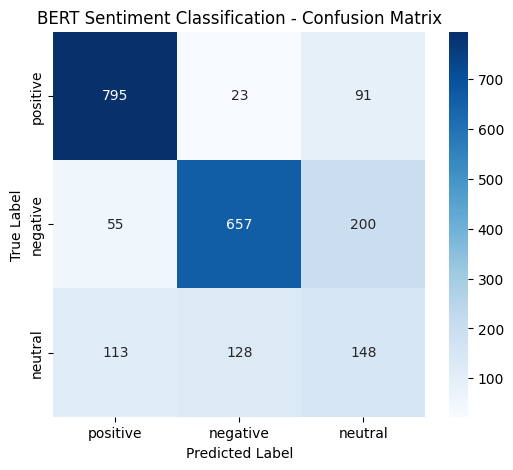

In [37]:
# Confusion matrix
cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=LABEL.vocab.itos,
    yticklabels=LABEL.vocab.itos
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("BERT Sentiment Classification - Confusion Matrix")
plt.show()